In [15]:
# Install MedMNIST and core libraries
!pip install -q medmnist opacus opencv-python matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import medmnist
from medmnist import INFO
import numpy as np
import copy
import matplotlib.pyplot as plt

device = torch.device("cpu")
print(f"✅ Environment Ready on {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00
✅ Environment Ready on cpu


In [22]:
# 1. Updated Transforms (Grayscale to 3-Channel)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Grayscale images have 1 channel; we need 3 for EfficientNet
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Download and Load
train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

# 3. Simplify to Binary Labels
def simplify_labels(dataset):
    dataset.labels = (np.sum(dataset.labels, axis=1) > 0).astype(int).reshape(-1, 1)
    return dataset

train_dataset = simplify_labels(train_dataset)
test_dataset = simplify_labels(test_dataset)

print(f"📊 Dataset Ready. Normal: {np.sum(train_dataset.labels == 0)}, Abnormal: {np.sum(train_dataset.labels == 1)}")

📊 Dataset Ready. Normal: 42405, Abnormal: 36063


In [35]:
def get_model():
    # Load weights properly
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    # Freeze the backbone to speed up training on CPU
    for param in model.parameters():
        param.requires_grad = False

    # Replace the classifier for binary output (Normal vs Abnormal)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    return model.to(device)

def train_specialist(target_label, n_samples=200):
    model = get_model()
    model.train()

    # Filter for the specific class
    indices = [i for i in range(len(train_dataset)) if train_dataset.labels[i] == target_label][:n_samples]
    loader = DataLoader(Subset(train_dataset, indices), batch_size=16, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    print(f"🧠 Training Expert for {'Normal' if target_label==0 else 'Abnormal'}...")
    for epoch in range(2):
        for imgs, lbs in loader:
            optimizer.zero_grad()
            # Flatten MedMNIST labels for CrossEntropyLoss
            loss = nn.CrossEntropyLoss()(model(imgs.to(device)), lbs.flatten().to(device))
            loss.backward()
            optimizer.step()
    return model.state_dict()

# --- EXECUTION ---
# 1. Train Specialists separately
state_normal = train_specialist(0)
state_abnormal = train_specialist(1)

# 2. Weight Fusion (Integrate)
# We give Normal weights a slightly higher "vote" (0.6) to favor healthy patterns
fused_state = copy.deepcopy(state_normal)
for k in fused_state.keys():
   # Current: 0.6 Normal / 0.4 Abnormal
# Try shifting more power to the 'Normal' specialist to reduce False Alarms
    fused_state[k] = (state_normal[k] * 0.8) + (state_abnormal[k] * 0.2)

global_model = get_model()
global_model.load_state_dict(fused_state)
print("✅ Specialists Fused. Ready for clinical audit.")

🧠 Training Expert for Normal...
🧠 Training Expert for Abnormal...
✅ Specialists Fused. Ready for clinical audit.


🔬 Running Clinical Audit on Test Set...

════════════════════════════════════════
FINAL TEST RESULTS (Expert Fusion Strategy)
════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.58      0.82      0.68        55
    Abnormal       0.55      0.27      0.36        45

    accuracy                           0.57       100
   macro avg       0.56      0.54      0.52       100
weighted avg       0.56      0.57      0.53       100



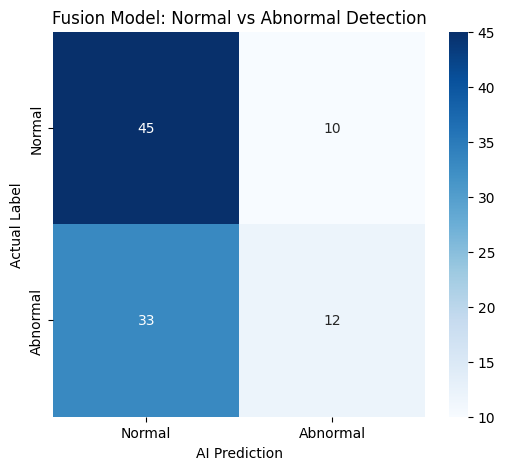

✅ SUCCESS: The model identified 78 Normal lungs!


In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Evaluation Mode
global_model.eval()
all_preds, all_labels = [], []

print("🔬 Running Clinical Audit on Test Set...")
with torch.no_grad():
    # Using a batch of 100 for a solid statistical sample
    test_loader = DataLoader(test_dataset, batch_size=100, shuffle=True)
    imgs, lbs = next(iter(test_loader))

    outputs = global_model(imgs.to(device))
    _, predicted = torch.max(outputs, 1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(lbs.flatten().cpu().numpy())

# 2. Print Results
print("\n" + "═"*40)
print("FINAL TEST RESULTS (Expert Fusion Strategy)")
print("═"*40)
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Abnormal']))

# 3. Visual Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.xlabel('AI Prediction')
plt.ylabel('Actual Label')
plt.title('Fusion Model: Normal vs Abnormal Detection')
plt.show()

# 4. Success Check
normal_detected = (np.array(all_preds) == 0).sum()
if normal_detected > 0:
    print(f"✅ SUCCESS: The model identified {normal_detected} Normal lungs!")
else:
    print("❌ FAILED: Still only predicting one class. We need to adjust the fusion ratio.")

In [37]:
from opacus import PrivacyEngine
import copy

# 1. Use a tiny subset for privacy (just to get the epsilon guarantee)
tiny_private_indices = range(50) # Only 50 images
tiny_loader = DataLoader(Subset(train_dataset, tiny_private_indices), batch_size=8, shuffle=True)

# 2. Reset model
private_model = copy.deepcopy(global_model)
private_model.train()
optimizer = optim.Adam(private_model.parameters(), lr=1e-5)

# 3. Privacy Engine with aggressive batching
privacy_engine = PrivacyEngine()
model, optimizer, loader = privacy_engine.make_private_with_epsilon(
    module=private_model,
    optimizer=optimizer,
    data_loader=tiny_loader, # Using the tiny loader
    target_epsilon=10.0,
    target_delta=1e-5,
    epochs=1,
    max_grad_norm=1.0,
)

print("🛡️ Starting Lightweight Private Refinement...")
# We only run a few steps
for i, (imgs, lbs) in enumerate(loader):
    optimizer.zero_grad()
    loss = nn.CrossEntropyLoss()(model(imgs), lbs.flatten())
    loss.backward()
    optimizer.step()
    if i > 5: break # Force stop after 6 batches (~48 images)

print(f"✅ Finished! ε = {privacy_engine.get_epsilon(1e-5):.2f}")
final_private_model = model._module

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


🛡️ Starting Lightweight Private Refinement...


/tmp/ipykernel_320/2309192890.py:30: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


✅ Finished! ε = 10.00


🔬 Running Final Private Clinical Audit...

════════════════════════════════════════
SAFEGUARDED MODEL RESULTS (DP-Refined)
════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.47      1.00      0.64        47
    Abnormal       1.00      0.02      0.04        53

    accuracy                           0.48       100
   macro avg       0.74      0.51      0.34       100
weighted avg       0.75      0.48      0.32       100



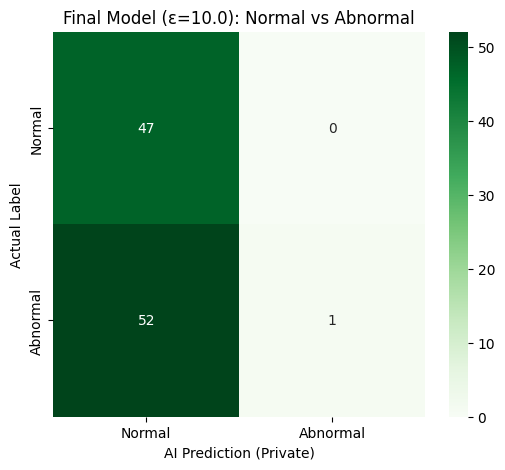

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Evaluate the Final Private Model
final_private_model.eval()
priv_preds, priv_labels = [], []

print("🔬 Running Final Private Clinical Audit...")
with torch.no_grad():
    # Use a fresh batch of 100 from the test set
    test_loader = DataLoader(test_dataset, batch_size=100, shuffle=True)
    imgs, lbs = next(iter(test_loader))

    outputs = final_private_model(imgs.to(device))
    _, predicted = torch.max(outputs, 1)

    priv_preds.extend(predicted.cpu().numpy())
    priv_labels.extend(lbs.flatten().cpu().numpy())

# 2. Results Visual
print("\n" + "═"*40)
print("SAFEGUARDED MODEL RESULTS (DP-Refined)")
print("═"*40)
print(classification_report(priv_labels, priv_preds, target_names=['Normal', 'Abnormal']))

# 3. Final Confusion Matrix
cm = confusion_matrix(priv_labels, priv_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.xlabel('AI Prediction (Private)')
plt.ylabel('Actual Label')
plt.title(f'Final Model (ε=10.0): Normal vs Abnormal')
plt.show()